In [69]:
from generate_utils import load_GraphModel, load_BiLSTMModel, load_TokenBiLSTMModel, load_FiLMSEModel, load_LoRASEModel, load_FiLMLoRASEModel, load_HyperNetworkSEModel, generate_files_with_nucleus
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import chord_id_features, get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, get_token_bilstm_embeddings_from_string_with_model, make_graph_ready_for_token_ids

In [70]:
print(chord_id_features.keys())

dict_keys([7, 36, 65, 94, 123, 152, 181, 210, 239, 268, 297, 326, 8, 37, 66, 95, 124, 153, 182, 211, 240, 269, 298, 327, 9, 38, 67, 96, 125, 154, 183, 212, 241, 270, 299, 328, 10, 39, 68, 97, 126, 155, 184, 213, 242, 271, 300, 329, 11, 40, 69, 98, 127, 156, 185, 214, 243, 272, 301, 330, 12, 41, 70, 99, 128, 157, 186, 215, 244, 273, 302, 331, 13, 42, 71, 100, 129, 158, 187, 216, 245, 274, 303, 332, 14, 43, 72, 101, 130, 159, 188, 217, 246, 275, 304, 333, 15, 44, 73, 102, 131, 160, 189, 218, 247, 276, 305, 334, 16, 45, 74, 103, 132, 161, 190, 219, 248, 277, 306, 335, 17, 46, 75, 104, 133, 162, 191, 220, 249, 278, 307, 336, 18, 47, 76, 105, 134, 163, 192, 221, 250, 279, 308, 337, 19, 48, 77, 106, 135, 164, 193, 222, 251, 280, 309, 338, 20, 49, 78, 107, 136, 165, 194, 223, 252, 281, 310, 339, 21, 50, 79, 108, 137, 166, 195, 224, 253, 282, 311, 340, 22, 51, 80, 109, 138, 167, 196, 225, 254, 283, 312, 341, 23, 52, 81, 110, 139, 168, 197, 226, 255, 284, 313, 342, 24, 53, 82, 111, 140, 169, 19

In [71]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [72]:
device_name = 'cuda:2'
device = torch.device(device_name)

graph_model_FiLM_path = 'saved_models/FiLM/graph/graph_model.pt'
transformer_graph_FiLM_path = 'saved_models/FiLM/graph/transformer_model.pt'

graph_model_LoRA_path = 'saved_models/LoRA/graph/graph_model.pt'
transformer_graph_LoRA_path = 'saved_models/LoRA/graph/transformer_model.pt'

graph_model_FiLMLoRA_path = 'saved_models/FiLMLoRA/graph/graph_model.pt'
transformer_graph_FiLMLoRA_path = 'saved_models/FiLMLoRA/graph/transformer_model.pt'

graph_model_HyperNetwork_path = 'saved_models/HyperNetwork/graph/graph_model.pt'
transformer_graph_HyperNetwork_path = 'saved_models/HyperNetwork/graph/transformer_model.pt'

bilstm_model_path = 'saved_models/HyperNetwork/bilstm/bilstm_model.pt'
transformer_bilstm_path = 'saved_models/HyperNetwork/bilstm/transformer_model.pt'

token_bilstm_model_path = 'saved_models/HyperNetwork/token_bilstm/bilstm_model.pt'
transformer_token_bilstm_path = 'saved_models/HyperNetwork/token_bilstm/transformer_model.pt'

In [73]:
graph_model_FiLM = load_GraphModel(graph_model_FiLM_path, device)
transformer_graph_FiLM = load_FiLMSEModel(
    tokenizer,
    device,
    checkpoint_path=transformer_graph_FiLM_path
)
graph_model_LoRA = load_GraphModel(graph_model_LoRA_path, device)
transformer_graph_LoRA = load_LoRASEModel(
    tokenizer,
    device,
    checkpoint_path=transformer_graph_LoRA_path
)
graph_model_FiLMLoRA = load_GraphModel(graph_model_FiLMLoRA_path, device)
transformer_graph_FiLMLoRA = load_FiLMLoRASEModel(
    tokenizer,
    device,
    checkpoint_path=transformer_graph_FiLMLoRA_path
)
graph_model_HyperNetwork = load_GraphModel(graph_model_HyperNetwork_path, device)
transformer_graph_HyperNetwork = load_HyperNetworkSEModel(
    tokenizer,
    device,
    checkpoint_path=transformer_graph_HyperNetwork_path
)

bilstm_model = load_BiLSTMModel(bilstm_model_path, device)
transformer_bilstm = load_HyperNetworkSEModel(
    tokenizer,
    device,
    checkpoint_path=transformer_bilstm_path
)

token_bilstm_model = load_TokenBiLSTMModel(token_bilstm_model_path, tokenizer, device)
transformer_token_bilstm = load_HyperNetworkSEModel(
    tokenizer,
    device,
    checkpoint_path=transformer_token_bilstm_path
)

In [74]:
graph_model_FiLM.eval()
transformer_graph_FiLM.eval()

graph_model_LoRA.eval()
transformer_graph_LoRA.eval()

graph_model_FiLMLoRA.eval()
transformer_graph_FiLMLoRA.eval()

graph_model_HyperNetwork.eval()
transformer_graph_HyperNetwork.eval()

bilstm_model.eval()
transformer_bilstm.eval()

token_bilstm_model.eval()
transformer_token_bilstm.eval()

HyperNetworkSEModel(
  (melody_proj): Linear(in_features=13, out_features=512, bias=True)
  (harmony_embedding): Embedding(355, 512)
  (hyper_q): HyperGuide(
    (layer_embedding): Embedding(8, 16)
    (head_embedding): Embedding(8, 16)
    (mlp): Sequential(
      (0): Linear(in_features=160, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
    )
    (gamma_proj): Linear(in_features=128, out_features=64, bias=True)
    (beta_proj): Linear(in_features=128, out_features=64, bias=True)
    (lora_A): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=512, bias=True)
    )
    (lora_B): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=512, bias=True)
    )
  )

In [75]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt
loading nott


In [76]:
# in_seq = 'b_A#:7_@2;A:min6_@2'
# in_seq = 'b_F#:7_@2;B:7_@2b_E:7_@2;A#:7_@2;'
# in_seq = 'b_A#:7_@2;A:min6_@2'
# in_seq = 'b_F:min_@2;A#:min_@2'
# in_seq = 'b_E:min6_@2;A:7_@2b_F:min6_@2;A#:7_@2'
# in_seq = 'G:maj;D:maj;G#:maj;D#:maj'
# in_seq = 'b_E:7_@2;A:7_@2b_F:7_@2;A#:7_@2'
in_seq = 'b_D:min11_@2;B:min11_@2b_C:min11_@2;F#:min11_@2'

In [77]:
y_graph_FiLM = get_graph_embeddings_from_string_with_model(in_seq, graph_model_FiLM)
y_graph_LoRA = get_graph_embeddings_from_string_with_model(in_seq, graph_model_LoRA)
y_graph_FiLMLoRA = get_graph_embeddings_from_string_with_model(in_seq, graph_model_FiLMLoRA)
y_graph_HyperNetwork = get_graph_embeddings_from_string_with_model(in_seq, graph_model_HyperNetwork)

y_bilstm = get_bilstm_embeddings_from_string_with_model(in_seq, bilstm_model)
y_token_bilstm = get_token_bilstm_embeddings_from_string_with_model(in_seq, token_bilstm_model)

D:min11 in vocab as: 82
B:min11 in vocab as: 343
C:min11 in vocab as: 24
F#:min11 in vocab as: 198
D:min11 in vocab as: 82
B:min11 in vocab as: 343
C:min11 in vocab as: 24
F#:min11 in vocab as: 198
D:min11 in vocab as: 82
B:min11 in vocab as: 343
C:min11 in vocab as: 24
F#:min11 in vocab as: 198
D:min11 in vocab as: 82
B:min11 in vocab as: 343
C:min11 in vocab as: 24
F#:min11 in vocab as: 198
D:min11 in vocab as: 82
B:min11 in vocab as: 343
C:min11 in vocab as: 24
F#:min11 in vocab as: 198
D:min11 in vocab as: 82
B:min11 in vocab as: 343
C:min11 in vocab as: 24
F#:min11 in vocab as: 198


In [78]:
# print(y_bilstm.shape)
# print(y_token_bilstm.shape)

In [79]:
# input_f_path = '/mnt/ssd2/maximos/data/gjt_melodies/gjt_CA_test/Autumn_Leaves.mxl'
# input_f_path = '/mnt/ssd2/maximos/data/gjt_melodies/gjt_CA_test/So_What.mxl'

input_f_path = '/media/maindisk/data/mel_harm_CA_all/gjt_CA_test/So_What.mxl'
# input_f_path = '/media/maindisk/data/mel_harm_CA_all/gjt_CA_test/Off_Minor.mxl'

piece_name = input_f_path.split('/')[-1].split('.')[0]
print(piece_name)

So_What


In [80]:
gen_out = generate_files_with_nucleus(
    transformer_graph_FiLM,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_no',
    guidance_vec = None,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
print(gen_out['gen_output_tokens'])

['<bar>', 'E:min', 'E:min', 'E:min', 'E:min', '<bar>', 'A:min', 'A:min', 'A:min', 'A:min', '<bar>', 'D#:min', 'D#:min', 'E:min', 'E:min', '<bar>', 'A:min', 'A:min', 'A:min', 'A:min', '<bar>', 'E:min', 'E:min', 'E:min', 'E:min', '<bar>', 'A:min', 'A:min', 'A:min', 'A:min', '<bar>', 'D#:min', 'D#:min', 'D#:min', 'D#:min', '<bar>', 'A:min', 'A:min', 'A:min', 'A:min', '<bar>', 'C:min', 'C:min', 'C:min', 'C:min', '<bar>', 'A#:maj', 'A#:maj', 'A#:maj', 'A#:maj', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min', '<bar>', 'A#:maj', 'A#:maj', 'A#:maj', 'A#:maj', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min', '<bar>', 'A#:maj', 'A#:maj', 'A#:maj', 'A#:maj']


In [81]:
gen_out = generate_files_with_nucleus(
    transformer_graph_FiLM,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_graph_FiLM',
    guidance_vec = y_graph_FiLM,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
print(gen_out['gen_output_tokens'])

['<bar>', 'E:min', 'E:min', 'E:min', 'E:min', '<bar>', 'F#:min7', 'F#:min7', 'F#:min7', 'F#:min7', '<bar>', 'F#:min7', 'F#:min7', 'F#:min7', 'F#:min7', '<bar>', 'F#:min7', 'F#:min7', 'F#:min7', 'F#:min7', '<bar>', 'F#:min7', 'F#:min7', 'F#:min7', 'F#:min7', '<bar>', 'F#:min7', 'F#:min7', 'F#:min7', 'F#:min7', '<bar>', 'C#:hdim7', 'C#:hdim7', 'D#:dim7', 'D#:dim7', '<bar>', 'A:maj7', 'A:maj7', 'A:maj7', 'A:maj7', '<bar>', 'F:min7', 'F:min7', 'F:min7', 'F:min7', '<bar>', 'C:7(b9)', 'D#:maj', 'D#:maj', 'D#:maj', '<bar>', 'C:min', 'C:min', 'F:min7', 'F:min7', '<bar>', 'C:min', 'C:min', 'C:min', 'C:min', '<bar>', 'F:min7', 'F:min7', 'F:min7', 'F:min7', '<bar>', 'C:7', 'C:7', 'C:7', 'C:7', '<bar>', 'F:min7', 'F:min7', 'F:min7', 'F:min7', '<bar>', 'G#:dim7', 'G#:dim7', 'G#:maj7', 'C#:7']


In [82]:
gen_out = generate_files_with_nucleus(
    transformer_graph_LoRA,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_graph_LoRA',
    guidance_vec = y_graph_LoRA,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
print(gen_out['gen_output_tokens'])

Skipping invalid chord <s> at step 36: Invalid chord label: <s>
['<bar>', 'B:sus2', 'G:7(#11)', 'B:7(b9)', 'B:dim', '<bar>', 'E:7(b9)', 'G#:sus4', 'C:dim7', 'D:maj7', '<bar>', 'D#:maj9', 'B:7(b9)', 'F:min', 'A:sus2', '<bar>', 'C#:min6', 'G:9', 'E:hdim7', 'A:7(#9)', '<bar>', 'C#:sus4', 'E:11', 'A#:13', 'F:7(#9)', '<bar>', 'G#:dim7', 'B:7', 'A:11', 'G:maj13', '<bar>', 'B:7(#11)', 'C:11', 'E:7', 'B:min7', '<bar>', '<s>', 'D:1', 'G:min', 'G#:maj6', '<bar>', 'A:hdim7', 'F#:7', 'C:hdim7', 'G:9', '<bar>', 'A#:7(#11)', 'C:min11', 'B:hdim7', 'E:7(#9)', '<bar>', 'G#:maj6', 'C#:maj7', 'D#:maj', 'C:min', '<bar>', 'C:min', 'C:13', 'A#:13', 'F#:7', '<bar>', 'F:min', 'C#:hdim7', 'E:1', 'F:maj7', '<bar>', 'E:min7', 'D:maj7', 'E:1', 'A:minmaj7', '<bar>', 'B:13', 'E:7', 'G:min', 'A:min9', '<bar>', 'A#:sus4', 'B:1', 'D:5', 'C:9']


In [83]:
gen_out = generate_files_with_nucleus(
    transformer_graph_FiLMLoRA,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_graph_FiLMLoRA',
    guidance_vec = y_graph_FiLMLoRA,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
print(gen_out['gen_output_tokens'])

Skipping invalid chord D#:1 at step 77: Invalid chord abbreviation 'bpedal'; see music21.harmony.CHORD_TYPES for valid abbreviations or specify all alterations.
['<bar>', 'F#:min7', 'F#:hdim7', 'E:min9', 'G:min6', '<bar>', 'F:1', 'C:7(b9)', 'C:11', 'E:maj7', '<bar>', '<bar>', 'C:maj', 'D#:maj9', 'B:7(b9)', '<bar>', 'E:7(b13)', 'E:1', 'A:min9', 'D:7(b9)', '<bar>', 'E:1', 'E:1', 'A:11', 'F:1', '<bar>', 'E:min11', 'D:maj9', 'C:maj', 'B:dim7', '<bar>', 'F:aug', 'D#:maj', 'G:7(b9)', 'A:9', '<bar>', 'D:1', 'E:min7', 'E:maj7', 'F:maj13', '<bar>', 'A#:7(b9)', 'D#:sus2', 'G:minmaj7', 'D#:aug', '<bar>', 'B:7', 'D#:sus2', 'A#:7(#9)', 'F:maj6', '<bar>', 'F:min9', 'F:min7', 'D#:11', 'F:min6', '<bar>', 'F:13', 'A#:9', 'C:1', 'F:min7', '<bar>', 'G#:min7', 'G:1', 'A#:dim7', 'F:min9', '<bar>', 'C:7(b9)', 'G:13', 'F#:1', 'C:7(b9)', '<bar>', 'F#:min', 'D#:maj', 'G:aug', 'D:11', '<bar>', 'C:aug', 'D#:1', 'C#:maj6', 'C:aug']


In [84]:
gen_out = generate_files_with_nucleus(
    transformer_graph_HyperNetwork,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_graph_HyperNetwork',
    guidance_vec = y_graph_HyperNetwork,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
out_graph_hypernetwork = gen_out['gen_output_tokens']
print(out_graph_hypernetwork)

['<bar>', 'E:min9', 'E:min9', 'E:min9', 'D:maj9', '<bar>', 'F#:min6', 'D:min9', 'D:min11', 'F#:hdim7', '<bar>', 'G:maj7', 'E:9', 'G:maj7', 'A:minmaj7', '<bar>', 'G:minmaj7', 'A:maj', 'A:maj', 'A:maj', '<bar>', 'E:hdim7', 'E:hdim7', 'E:min9', 'E:min9', '<bar>', 'D:maj', 'D:maj', 'D:maj', 'D:maj', '<bar>', 'F#:min13', 'D:maj6', 'B:min7', 'G:maj', '<bar>', 'A:maj7', 'C#:min7', 'F#:min7', 'F#:min7', '<bar>', 'D#:11', 'C:min', 'F:min', 'F:min', '<bar>', 'A:7(#9)', 'A:7(#9)', 'G:min', 'D#:maj', '<bar>', 'C:min', 'C:min', 'C:min', 'C:min', '<bar>', 'G#:dim7', 'D#:maj7', 'D:7(#9)', 'A#:maj6', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min7', '<bar>', 'G:min7', 'G:min7', 'G:min7', 'G:min7', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min', '<bar>', 'D#:maj9', 'A#:min', 'A#:13', 'A:aug']


In [85]:
gen_out = generate_files_with_nucleus(
    transformer_bilstm,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_bilstm',
    guidance_vec = y_bilstm,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
out_bilstm_hypernetwork = gen_out['gen_output_tokens']
print(out_bilstm_hypernetwork)

['<bar>', 'C:maj7', 'C:maj7', 'C:maj7', 'C:maj7', '<bar>', 'C:maj7', 'C:maj7', 'A#:maj7', 'A#:maj7', '<bar>', 'C:maj7', 'C:maj7', 'C:maj7', 'C:maj7', '<bar>', 'C:maj7', 'C:maj7', 'C:maj7', 'C:maj7', '<bar>', 'C:maj7', 'E:min', 'E:min', 'E:min', '<bar>', 'A#:min', 'D:maj7', 'A:7(#9)', 'C:maj7', '<bar>', 'A:min9', 'A:min9', 'A:min13', 'D:maj9', '<bar>', 'D:min7', 'D:min7', 'D:min7', 'D:min7', '<bar>', 'F:min7', 'F:min7', 'F:min7', 'F:min7', '<bar>', 'D#:maj7', 'D#:maj7', 'D#:maj7', 'D#:maj7', '<bar>', 'F:min7', 'F:min7', 'F:min7', 'F:min7', '<bar>', 'D#:maj7', 'D#:maj7', 'D#:maj7', 'D#:maj7', '<bar>', 'F:min7', 'F:min7', 'F:min7', 'F:min7', '<bar>', 'D#:maj7', 'D#:maj7', 'D#:maj7', 'D#:maj7', '<bar>', 'F:min', 'F:min', 'F:min', 'F:min', '<bar>', 'D#:maj7', 'D#:maj7', 'D#:maj7', 'D#:maj7']


In [86]:
gen_out = generate_files_with_nucleus(
    transformer_token_bilstm,
    tokenizer,
    input_f_path=input_f_path,
    mxl_folder_out=None,
    midi_folder_out='midi_tests',
    name_suffix=f'{piece_name}_token_bilstm',
    guidance_vec = y_token_bilstm,
    use_constraints=False,
    intertwine_bar_info=True,
    normalize_tonality=True,
    temperature=1.0,
    p=0.9,
    unmasking_order='certain',
    create_gen=True,
    create_real=False
)
out_token_hypernetwork = gen_out['gen_output_tokens']
print(out_token_hypernetwork)

['<bar>', 'A:min', 'E:min9', 'E:min9', 'E:min9', '<bar>', 'B:min7', 'D:min9', 'A#:maj7', 'A#:maj7', '<bar>', 'A:min9', 'A:min9', 'E:min9', 'E:min7', '<bar>', 'D:min9', 'D:min9', 'D:min9', 'D:min9', '<bar>', 'E:hdim7', 'D:maj7', 'E:min9', 'E:min9', '<bar>', 'C:maj7', 'C:maj7', 'C:maj7', 'C:maj7', '<bar>', 'D:7(b9)', 'G:maj7', 'F#:dim7', 'E:sus2', '<bar>', 'F:maj7', 'F:maj7', 'F#:min7', 'F#:min7', '<bar>', 'F:min7', 'C:min9', 'C:min9', 'A#:11', '<bar>', 'D#:maj6', 'D#:maj7', 'D#:maj7', 'D#:maj7', '<bar>', 'C:min', 'G:hdim7', 'D#:aug', 'C:min', '<bar>', 'C:min9', 'C:min9', 'C:min9', 'F:min11', '<bar>', 'F:9', 'G#:sus4', 'B:5', 'F:9', '<bar>', 'A#:7', 'A#:7', 'A#:7', 'A#:7', '<bar>', 'F:min', 'D#:maj7', 'C:maj7', 'C:min', '<bar>', 'D#:maj9', 'A#:maj', 'D#:maj9', 'D#:maj9']


In [87]:
print(gen_out.keys())

dict_keys(['gen_output_tokens', 'gen_output_token_ids', 'harmony_real_tokens', 'gen_score', 'real_score', 'guide_score', 'hidden'])


In [88]:
print(gen_out['gen_output_token_ids'][0])

tensor([  6, 269, 138, 138, 138,   6, 334,  80, 304, 304,   6, 283, 283, 138,
        131,   6,  80,  80,  80,  80,   6, 136,  72, 138, 138,   6,  14,  14,
         14,  14,   6,  90, 217, 193, 128,   6, 159, 159, 189, 189,   6, 160,
         22,  22, 315,   6, 104, 101, 101, 101,   6,   8, 223,  96,   8,   6,
         22,  22,  22, 169,   6, 168, 243, 349, 168,   6, 303, 303, 303, 303,
          6, 153, 101,  14,   8,   6, 108, 297, 108, 108], device='cuda:2')


In [89]:
m = make_graph_ready_for_token_ids(gen_out['gen_output_token_ids'][0].tolist(), tokenizer)

In [90]:
m.make_graph_of_segment(0,4)
m.make_bilstm_seq_of_segment(0,4)

In [91]:
print(m.segment_tokens)

tensor([269, 138, 334,  80, 304, 283, 138, 131,  80])


In [92]:
cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)

start_bar = 0
for seq_len in [16, 8, 4, 2]:
    step = seq_len//2
    end_bar = start_bar + seq_len
    while end_bar <= 16:
        print(f'start_bar: {start_bar} - end_bar: {end_bar}')
        m.make_graph_of_segment(start_bar, end_bar)
        tmp_graph_emb = graph_model_HyperNetwork(m.segment_graph.to(device))
        print(f'graph : {cos(y_graph_HyperNetwork, tmp_graph_emb).item()}')
        m.make_bilstm_seq_of_segment(start_bar, end_bar)
        tmp_bilstm_emb = bilstm_model(
            m.segment_bilstm.unsqueeze(0).to(device),
            torch.tensor([m.segment_bilstm.shape[0]]).to(device)
        )
        print(f'bilstm: {cos(y_bilstm, tmp_bilstm_emb).item()}')
        tmp_token_emb = token_bilstm_model(
            m.segment_tokens.unsqueeze(0).to(device),
            torch.tensor([len(m.segment_tokens)]).to(device)
        )
        print(f'token : {cos(y_token_bilstm, tmp_token_emb).item()}')
        start_bar += step
        end_bar = start_bar + seq_len
    start_bar = 0

start_bar: 0 - end_bar: 16
graph : 0.984227180480957
bilstm: 0.9972138404846191
token : 0.9885774254798889
start_bar: 0 - end_bar: 8
graph : 0.9861109852790833
bilstm: 0.9974489808082581
token : 0.9870457053184509
start_bar: 4 - end_bar: 12
graph : 0.9855582118034363
bilstm: 0.9977270364761353
token : 0.9862763285636902
start_bar: 8 - end_bar: 16
graph : 0.9820557236671448
bilstm: 0.9975717067718506
token : 0.9873743653297424
start_bar: 0 - end_bar: 4
graph : 0.9859203696250916
bilstm: 0.9987342357635498
token : 0.9851284623146057
start_bar: 2 - end_bar: 6
graph : 0.9864684343338013
bilstm: 0.998873233795166
token : 0.9874169826507568
start_bar: 4 - end_bar: 8
graph : 0.9851255416870117
bilstm: 0.998399019241333
token : 0.9867731332778931
start_bar: 6 - end_bar: 10
graph : 0.9875727891921997
bilstm: 0.9985689520835876
token : 0.9849659204483032
start_bar: 8 - end_bar: 12
graph : 0.9838797450065613
bilstm: 0.9981981515884399
token : 0.9826743602752686
start_bar: 10 - end_bar: 14
graph :

In [93]:
print(y_token_bilstm.shape)
print(tmp_token_emb.shape)

torch.Size([1, 128])
torch.Size([1, 128])


In [94]:
import matplotlib.pyplot as plt

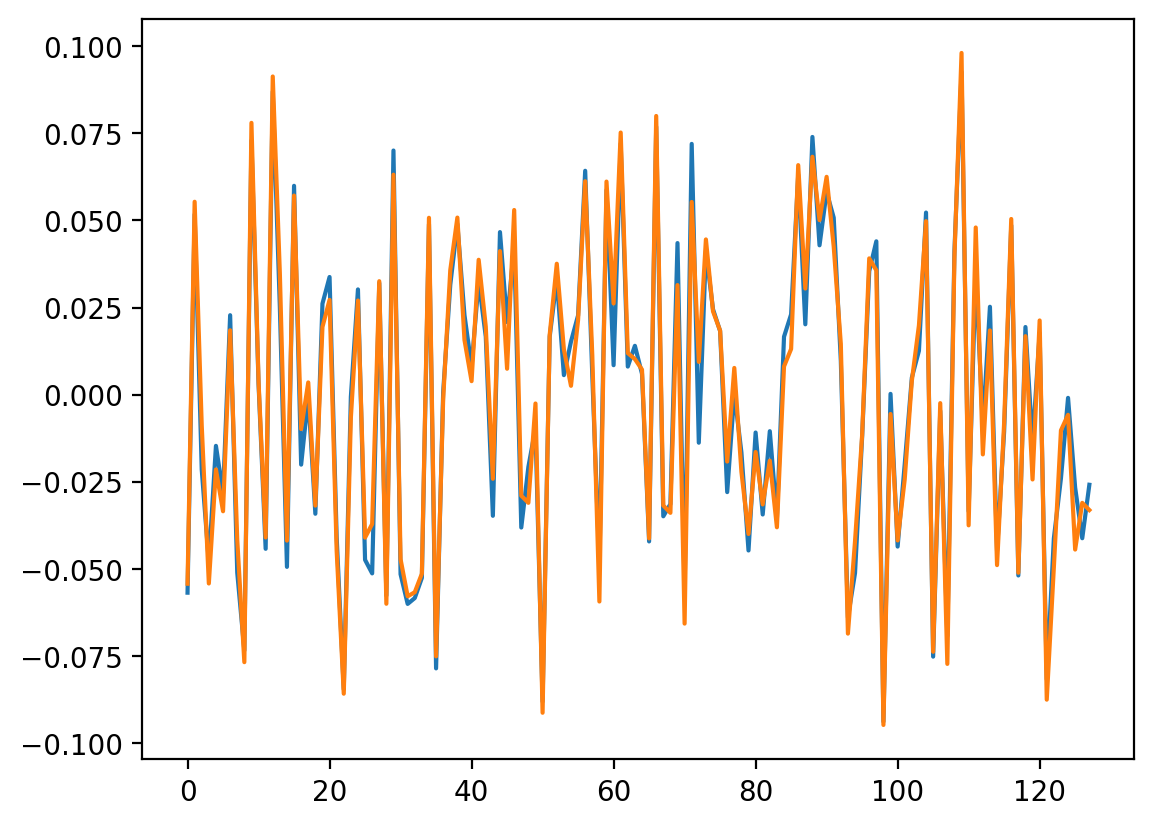

In [95]:
plt.plot(y_token_bilstm.detach().cpu()[0,:].numpy())
plt.plot(tmp_token_emb.detach().cpu()[0,:].numpy())

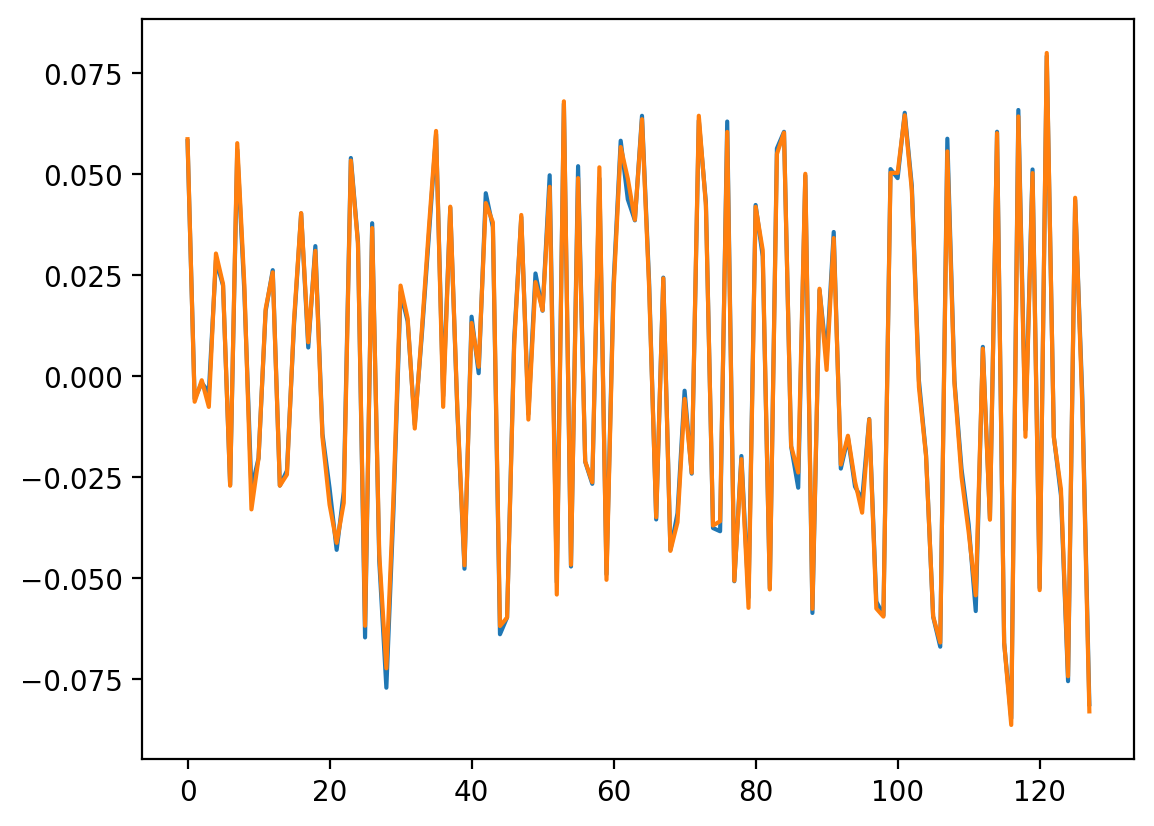

In [96]:
plt.plot(y_bilstm.detach().cpu()[0,:].numpy())
plt.plot(tmp_bilstm_emb.detach().cpu()[0,:].numpy())